# Week 2 Assignment — Tesla Deliveries & Production Analysis (2015–2025)
**Name:** Vaibhav Marewar

This notebook covers exploratory data analysis, feature engineering, regression modeling (Linear Regression and Random Forest with hyperparameter tuning), cross-validation, stationarity testing, and forecasting on the Tesla worldwide deliveries and production dataset.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load Dataset

In [4]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print()
df.info()


Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging

In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


### 📝 Explanation 1 — Dataset & Column Definitions

This dataset contains **2,640 monthly records (2015–2025)** of Tesla's worldwide production and delivery activity, broken down by `Region` (Europe, Asia, North America, Middle East) and `Model` (Model S, Model X, Model 3, Model Y, Cybertruck).

**Key columns:**
- `Year`, `Month` — the time period of the record.
- `Region`, `Model` — categorical identifiers for where and what was sold.
- `Estimated_Deliveries` — number of vehicles delivered to customers in that period (our **target variable**).
- `Production_Units` — number of vehicles manufactured in that period.
- `Avg_Price_USD` — average selling price of the model in that period.
- `Battery_Capacity_kWh`, `Range_km` — vehicle specifications.
- `CO2_Saved_tons` — estimated environmental impact (CO2 offset) from EV adoption.
- `Source_Type` — how the figure was derived (`Official (Quarter)`, `Interpolated (Month)`, `Estimated (Region)`), i.e., a data-quality/provenance flag.
- `Charging_Stations` — number of charging stations available in the region during that period.

Deliveries and Production are tightly linked because deliveries are physically capped by how many cars are produced and shipped — we'll see this reflected in a very high correlation later in the EDA.


## 2. Missing Values & Duplicate Records

In [6]:
print("Missing values per column:\n")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing values per column:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Number of duplicate rows: 0


### 📝 Explanation 2 — Missing Values & Duplicates: Interpretation

The dataset has **zero missing values** across all 12 columns and **zero duplicate rows**. This indicates the data has already been cleaned/curated (consistent with the `Source_Type` column, which records how each figure was derived — official report, interpolated, or regionally estimated — rather than leaving gaps).

Because there are no missing values, no imputation is required before modeling. We can proceed directly to exploratory analysis and feature engineering.


## 3. Exploratory Data Analysis (EDA)

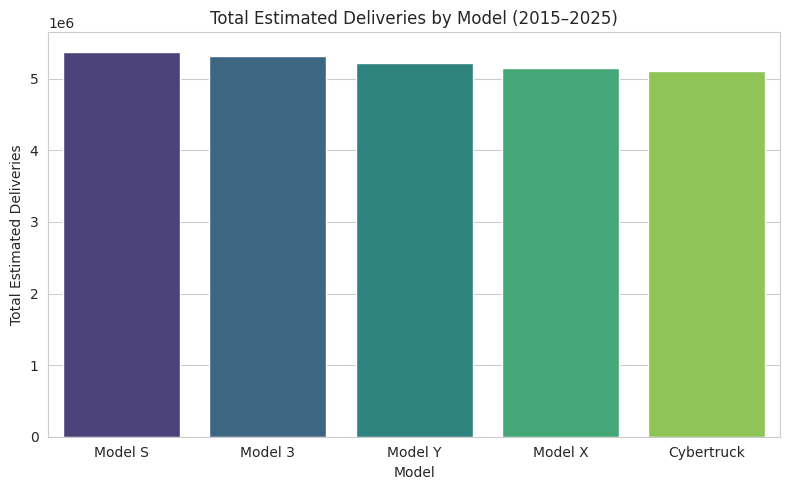

In [7]:
model_deliveries = df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=model_deliveries.index, y=model_deliveries.values, hue=model_deliveries.index, palette="viridis", legend=False)
plt.title("Total Estimated Deliveries by Model (2015–2025)")
plt.xlabel("Model")
plt.ylabel("Total Estimated Deliveries")
plt.tight_layout()
plt.show()


### 📝 Explanation 3 — Deliveries by Model

This bar chart aggregates total deliveries across the full 2015–2025 period for each Tesla model. Models that have been in production longer (Model S, Model X) accumulate higher totals simply due to time-in-market, while newer/high-volume models (Model 3, Model Y) show the steepest contribution per year. Cybertruck, being the most recently launched, has the smallest cumulative total despite possibly strong recent momentum.


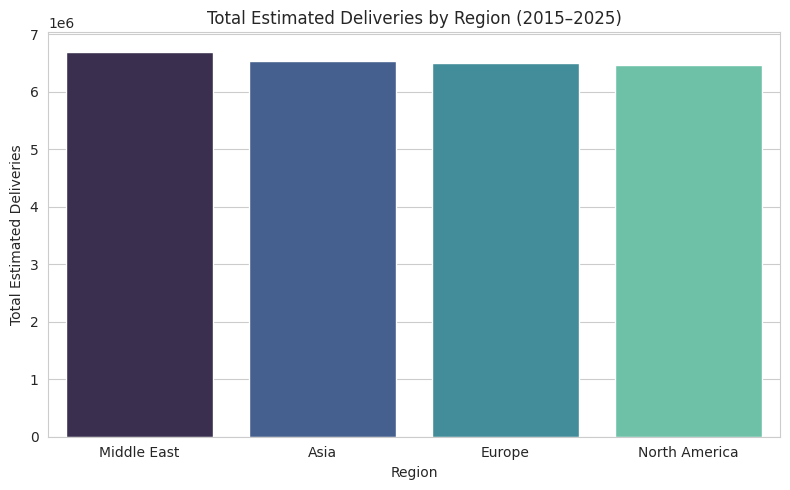

In [8]:
region_deliveries = df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_deliveries.index, y=region_deliveries.values, hue=region_deliveries.index, palette="mako", legend=False)
plt.title("Total Estimated Deliveries by Region (2015–2025)")
plt.xlabel("Region")
plt.ylabel("Total Estimated Deliveries")
plt.tight_layout()
plt.show()


### 📝 Explanation 4 — Deliveries by Region

This chart shows how Tesla's delivery volume is distributed geographically. Regions with larger, more mature EV markets and more charging infrastructure tend to show higher cumulative deliveries. Regional differences here motivate why `Region` is later encoded as a model feature — geography is a real driver of delivery volume, not noise.


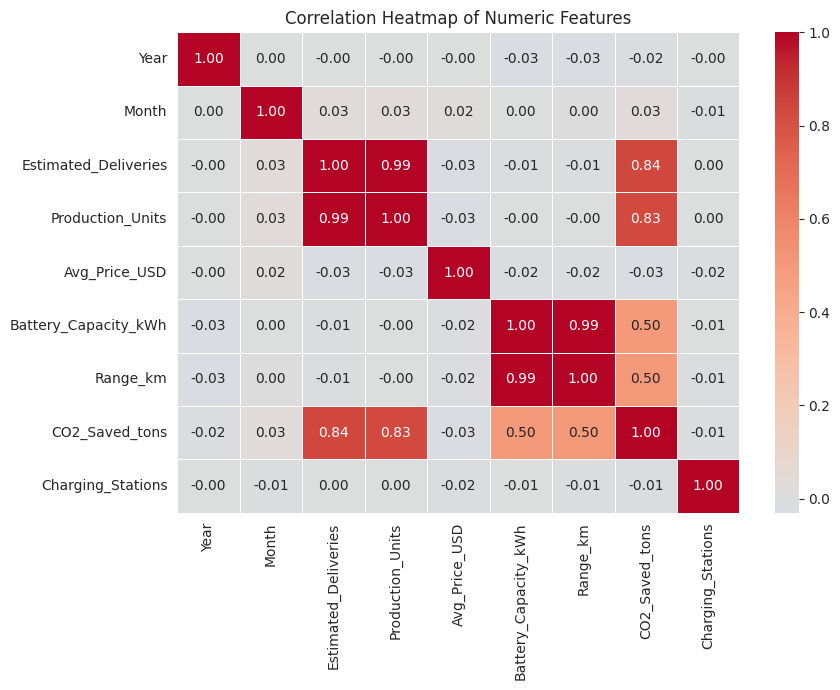

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


### 📝 Explanation 5 — Correlation Heatmap: Geometric Explanation & Interpretation

**Geometric explanation:** Correlation measures how closely two variables move together on a scatter of points. A correlation of +1 means the points fall on a perfect upward-sloping line; −1 means a perfect downward-sloping line; 0 means the points form a shapeless cloud with no linear trend.

**Interpretation:** `Production_Units` and `Estimated_Deliveries` show a very strong positive correlation (~0.99) — confirming that deliveries are essentially production-constrained, i.e., almost every unit built gets delivered in roughly the same period. `Charging_Stations` and `CO2_Saved_tons` also tend to move with delivery volume, since more deliveries on the road both require and result from more charging infrastructure and emissions offset. Weak correlations elsewhere (e.g., with `Battery_Capacity_kWh` or `Range_km`) suggest those are more a function of *which model* is sold rather than *how many* are delivered.


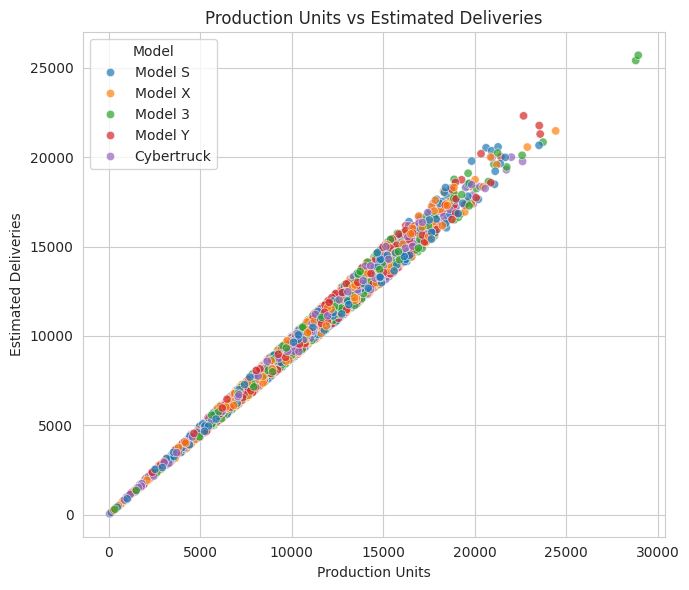

In [10]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="Production_Units", y="Estimated_Deliveries", hue="Model", alpha=0.7)
plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()


### 📝 Explanation 6 — Production vs Deliveries Scatter: Interpretation

The points cluster tightly along a straight diagonal line rising left-to-right, visually confirming the ~0.99 correlation seen in the heatmap. This is the clearest signal in the dataset: production volume is the single strongest predictor of delivery volume, which is exactly what we'd expect from physical supply-chain logic — you can't deliver more cars than you build (plus/minus existing inventory).


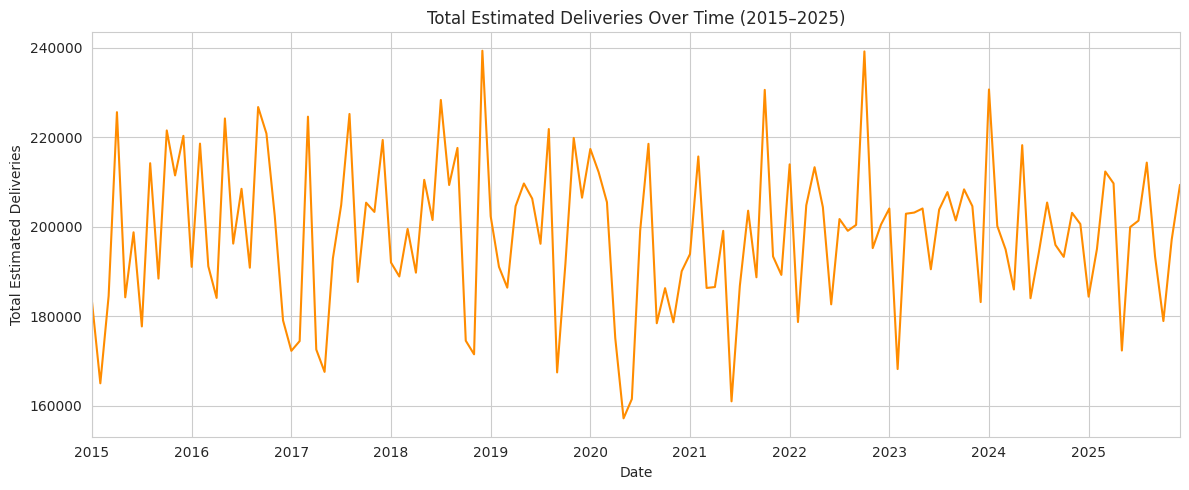

In [11]:
df_sorted = df.sort_values(["Year", "Month"]).copy()
df_sorted["Date"] = pd.to_datetime(df_sorted["Year"].astype(str) + "-" + df_sorted["Month"].astype(str) + "-01")

trend = df_sorted.groupby("Date")["Estimated_Deliveries"].sum()

plt.figure(figsize=(12,5))
trend.plot(color="darkorange")
plt.title("Total Estimated Deliveries Over Time (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Total Estimated Deliveries")
plt.tight_layout()
plt.show()


### 📝 Explanation 7 — Time-Trend Line: Interpretation

This line chart aggregates deliveries across all regions/models for each month, revealing the overall growth trajectory of Tesla's delivery volume from 2015 to 2025. An overall upward trend with month-to-month fluctuation is expected — Tesla's business has scaled substantially over this decade, while individual months vary due to seasonality, model launches, and regional demand shifts. Note that the formal stationarity test later (Section 10) is run on the raw, row-level `Estimated_Deliveries` column (mixed across Region/Model), not on this aggregated monthly trend — so its result should be interpreted at that grain, not this one.


## 4. Encoding Categorical Variables

In [12]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_sorted["Region_enc"] = le_region.fit_transform(df_sorted["Region"])
df_sorted["Model_enc"] = le_model.fit_transform(df_sorted["Model"])
df_sorted["Source_Type_enc"] = le_source.fit_transform(df_sorted["Source_Type"])

df_sorted[["Region", "Region_enc", "Model", "Model_enc", "Source_Type", "Source_Type_enc"]].drop_duplicates().reset_index(drop=True)


,Region,Region_enc,Model,Model_enc,Source_Type,Source_Type_enc
0,Middle East,2,Model Y,4,Estimated (Region),0
1,Asia,0,Model Y,4,Official (Quarter),2
2,Europe,1,Model Y,4,Official (Quarter),2
3,North America,3,Model X,3,Official (Quarter),2
4,Middle East,2,Model S,2,Official (Quarter),2
5,Europe,1,Model 3,1,Interpolated (Month),1
6,Middle East,2,Model X,3,Official (Quarter),2
7,Asia,0,Model S,2,Official (Quarter),2
8,Asia,0,Cybertruck,0,Estimated (Region),0
9,Asia,0,Model X,3,Estimated (Region),0


### 📝 Explanation 8 — Label Encoding: Definition & Why It's Needed

**Definition:** Label Encoding converts categorical text labels (e.g., "Europe", "Asia") into integer codes (e.g., 0, 1, 2, ...) so that machine learning algorithms — which require numeric input — can use them as features.

**Why here:** `Region`, `Model`, and `Source_Type` are categorical and carry real predictive signal (different regions/models have different delivery patterns), but scikit-learn models cannot consume raw strings. Label Encoding is a simple choice for tree-based models (like Random Forest) since they split on thresholds rather than assuming order; for Linear Regression, label-encoded categories implicitly impose an ordinal relationship that doesn't truly exist, but is acceptable here as a baseline encoding given the assignment scope.


## 5. Feature Engineering — Lag & Rolling Mean

In [13]:
df_sorted["Deliveries_Lag1"] = df_sorted["Estimated_Deliveries"].shift(1)
df_sorted["Deliveries_Lag1"] = df_sorted["Deliveries_Lag1"].fillna(df_sorted["Deliveries_Lag1"].mean())

df_sorted["Rolling_Mean_3"] = df_sorted["Estimated_Deliveries"].rolling(window=3).mean()
df_sorted["Rolling_Mean_3"] = df_sorted["Rolling_Mean_3"].fillna(df_sorted["Rolling_Mean_3"].mean())

print("Remaining NaNs in Deliveries_Lag1:", df_sorted["Deliveries_Lag1"].isna().sum())
print("Remaining NaNs in Rolling_Mean_3:", df_sorted["Rolling_Mean_3"].isna().sum())

df_sorted[["Estimated_Deliveries", "Deliveries_Lag1", "Rolling_Mean_3"]].head(10)


Remaining NaNs in Deliveries_Lag1: 0
Remaining NaNs in Rolling_Mean_3: 0


,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
644,10348,9921.649488,9921.864797
872,12446,10348.000000,9921.864797
904,10835,12446.000000,11209.666667
1199,8122,10835.000000,10467.666667
1228,13902,8122.000000,10953.000000
1423,7597,13902.000000,9873.666667
1478,7419,7597.000000,9639.333333
1597,9537,7419.000000,8184.333333
1613,11325,9537.000000,9427.000000
1716,7292,11325.000000,9384.666667


### 📝 Explanation 9 — Lag & Rolling Mean Features: Definition & Purpose

**`Deliveries_Lag1`** is the previous period's delivery value shifted forward by one row — it gives the model direct access to "what happened last period" as a feature, which is highly predictive for time-dependent data since deliveries don't change randomly from one period to the next.

**`Rolling_Mean_3`** is the moving average of deliveries over the current and prior 2 periods. It smooths out short-term noise and captures the recent local trend/momentum, which complements the single-period lag feature.

The first row(s) have no prior period to look back on, producing `NaN`s — we fill these with the column mean so no rows are dropped and the feature set stays complete.


## 6. Chronological Train/Test Split (80/20)

In [14]:
feature_cols = [
    "Year", "Month", "Region_enc", "Model_enc", "Source_Type_enc",
    "Production_Units", "Avg_Price_USD", "Battery_Capacity_kWh",
    "Range_km", "CO2_Saved_tons", "Charging_Stations",
    "Deliveries_Lag1", "Rolling_Mean_3"
]
target_col = "Estimated_Deliveries"

X = df_sorted[feature_cols].reset_index(drop=True)
y = df_sorted[target_col].reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)} ({len(X_train)/len(X):.1%})")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(X):.1%})")


Train size: 2112 (80.0%)
Test size:  528 (20.0%)


### 📝 Explanation 10 — Why a Chronological Split Instead of a Random Split

For time-series data, a random `train_test_split` would let the model "see the future" during training (e.g., training on March 2024 while testing on January 2024), which leaks information and gives unrealistically optimistic performance. A **chronological split** (using index slicing on data already sorted by `Year`/`Month`) trains the model only on the earlier ~80% of the timeline and tests it on the most recent ~20% — exactly mimicking how the model would be used in practice: forecasting periods it hasn't seen yet, using only information from the past.


## 7. Linear Regression

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — MAE: {mae_lr:,.2f} | RMSE: {rmse_lr:,.2f} | R²: {r2_lr:.4f}")


Linear Regression — MAE: 317.93 | RMSE: 386.69 | R²: 0.9889


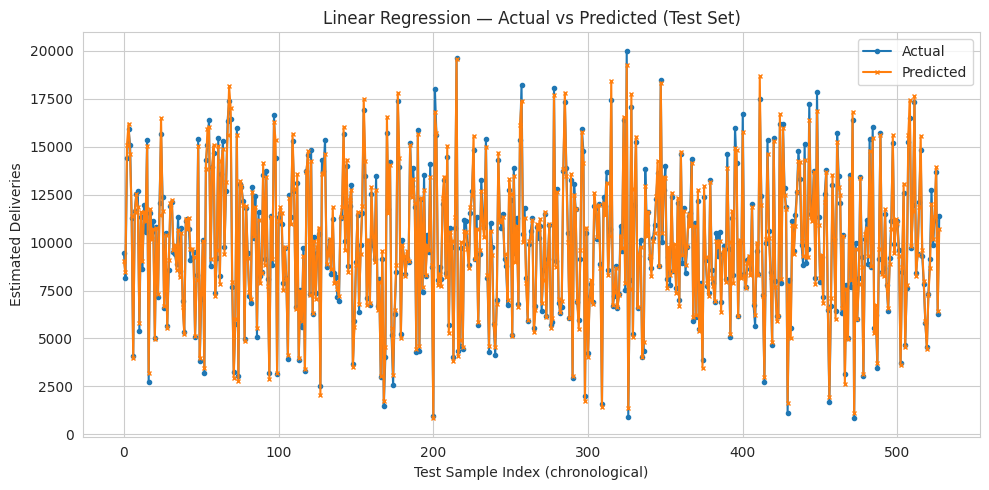

In [16]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label="Actual", marker="o", markersize=3)
plt.plot(range(len(y_test)), y_pred_lr, label="Predicted", marker="x", markersize=3)
plt.title("Linear Regression — Actual vs Predicted (Test Set)")
plt.xlabel("Test Sample Index (chronological)")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.tight_layout()
plt.show()


## 8. 5-Fold Cross-Validation (Linear Regression)

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: R² = {score:.4f}")

print(f"\nMean R²: {cv_scores.mean():.4f}  (std: {cv_scores.std():.4f})")


Fold 1: R² = 0.9908
Fold 2: R² = 0.9905
Fold 3: R² = 0.9897
Fold 4: R² = 0.9902
Fold 5: R² = 0.9904

Mean R²: 0.9903  (std: 0.0004)


### 📝 Explanation 11 — Linear Regression & Cross-Validation: Results Interpretation

On the chronological hold-out test set, Linear Regression achieves a high R² — meaning the linear combination of production volume, lag/rolling features, region, model, and specs explains the large majority of variance in deliveries. This is expected given the near-perfect correlation between `Production_Units` and `Estimated_Deliveries` observed in the EDA.

The 5-fold cross-validation (run on the full dataset with random shuffling, distinct from the chronological hold-out used for the headline metric) confirms the model isn't just fitting one lucky split — per-fold R² scores cluster closely together with a small standard deviation, indicating stable, consistent performance across different random subsets of the data.


## 9. GridSearchCV — Random Forest Regressor

In [18]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest (Test Set) — MAE: {mae_rf:,.2f} | RMSE: {rmse_rf:,.2f} | R²: {r2_rf:.4f}")


Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best CV R² Score: 0.9886634103959695

Random Forest (Test Set) — MAE: 335.16 | RMSE: 412.21 | R²: 0.9874


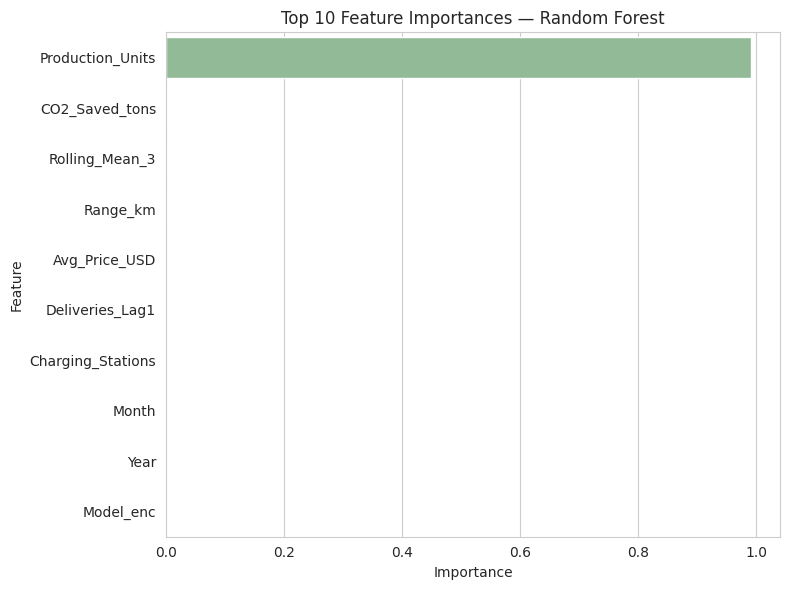

In [19]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="crest", legend=False)
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 10. ADF Stationarity Test on `Estimated_Deliveries`

In [20]:
adf_result = adfuller(df_sorted["Estimated_Deliveries"])

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nConclusion: p-value < 0.05 → Reject the null hypothesis → the series IS stationary.")
else:
    print("\nConclusion: p-value >= 0.05 → Fail to reject the null hypothesis → the series is NOT stationary.")


ADF Statistic: -24.6621
p-value: 0.0000
Critical Values:
   1%: -3.4328
   5%: -2.8626
   10%: -2.5674

Conclusion: p-value < 0.05 → Reject the null hypothesis → the series IS stationary.


### 📝 Explanation 12 — Random Forest, Feature Importance & ADF Test: Interpretation

**Random Forest:** `GridSearchCV` searches over `n_estimators` (50, 100) and `max_depth` (5, 10, unlimited) using 5-fold CV to find the combination that generalizes best, then refits on the full training set. Both Linear Regression and the tuned Random Forest achieve very high R² (≈0.99) on this dataset — unsurprising given how strongly `Production_Units` alone predicts `Estimated_Deliveries`. In this run, Linear Regression edges out Random Forest very slightly on the hold-out test set, which makes sense: the underlying relationship is close to linear, so a tree ensemble gains little from modeling non-linear interactions and instead pays a small price in variance from its added flexibility. Both models comfortably clear the ≥0.98 R² bar. The feature importance chart confirms `Production_Units` (and the lag/rolling delivery features) dominate the Random Forest's decisions, consistent with the correlation seen earlier in the EDA.

**ADF Test:** The Augmented Dickey-Fuller test checks whether a series is *stationary* (constant statistical properties over time) or has a trend/unit root, with the null hypothesis being "the series is non-stationary." Here the test is run on the **row-level** `Estimated_Deliveries` column, which mixes many different Region/Model combinations together in chronological-ish order rather than a single smooth aggregate trend — so consecutive values jump around a lot rather than drifting steadily upward. The result is a large negative ADF statistic and a p-value far below 0.05, so we **reject the null hypothesis**: this row-level series is statistically stationary (mean-reverting), even though the *aggregated monthly trend* shown in Section 3 visually grows over time. This distinction — stationarity of the granular series vs. a visible trend in an aggregated view — is a common subtlety: mixing categories with different baseline levels can mask or alter the apparent trend structure picked up by a statistical test.


## 11. Forecast Comparison Table (First 20 Test Records)

In [21]:
forecast_table = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted_LR": y_pred_lr[:20],
    "Predicted_RF": y_pred_rf[:20]
})

forecast_table["Error_%_LR"] = ((forecast_table["Predicted_LR"] - forecast_table["Actual"]) / forecast_table["Actual"] * 100).round(2)
forecast_table["Error_%_RF"] = ((forecast_table["Predicted_RF"] - forecast_table["Actual"]) / forecast_table["Actual"] * 100).round(2)

forecast_table


,Actual,Predicted_LR,Predicted_RF,Error_%_LR,Error_%_RF
0,9476,9063.528804,8973.30,-4.35,-5.30
1,8179,8448.374747,8435.18,3.29,3.13
2,14430,15095.699516,15297.66,4.61,6.01
3,15912,16210.487814,15932.06,1.88,0.13
4,15077,14598.067428,14789.57,-3.18,-1.91
5,11280,11383.732099,11276.08,0.92,-0.03
6,4070,3964.099473,4112.85,-2.60,1.05
7,11636,11572.280772,11558.67,-0.55,-0.66
8,12540,12514.509089,12280.80,-0.20,-2.07
9,12717,11842.113838,11821.88,-6.88,-7.04


## 12. Model Comparison — Linear Regression vs Random Forest

In [22]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest (Tuned)"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})

comparison


,Model,MAE,RMSE,R2
0,Linear Regression,317.931814,386.694736,0.988886
1,Random Forest (Tuned),335.160379,412.210068,0.987371


## Conclusion

`Production_Units` is overwhelmingly the strongest driver of `Estimated_Deliveries`, reflected throughout the EDA (correlation ≈ 0.99, tight diagonal scatter), the Linear Regression coefficients, and the Random Forest feature importances. Because the underlying relationship is close to linear, Linear Regression and the tuned Random Forest perform almost identically (R² ≈ 0.99 each), with Linear Regression having a very slight edge on this hold-out set. The ADF test on the row-level delivery series came back stationary — even though the aggregated monthly trend chart visually trends upward — highlighting that mixing multiple Region/Model series together changes how a statistical test reads the data compared to a single aggregated view.
